In [46]:
! pip install monai

In [47]:
"""
MAE-based Unsupervised Anomaly Detection for FCD (Focal Cortical Dysplasia)
===========================================================================
Pipeline:
  1. Train MaskedAutoEncoderViT on healthy (HC) MRI volumes only
  2. At inference, reconstruct lesion (FCD) volumes
  3. Compute residual map — lesion appears as high-error region
  4. Threshold residual to get binary lesion mask
  5. Evaluate against ground-truth masks
"""

import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from glob import glob
from scipy import ndimage
from einops import rearrange
import torch.nn.functional as F
 
from monai.networks.nets.masked_autoencoder_vit import MaskedAutoEncoderViT
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd,
    NormalizeIntensityd, ResizeWithPadOrCropd, EnsureTyped,
    RandFlipd, RandAffined, RandGaussianNoised, RandAdjustContrastd,
    SpatialPadd, RandSpatialCropd,
)
from monai.data import CacheDataset, DataLoader, Dataset
from monai.losses import SSIMLoss

In [48]:
# =============================================================================
# 0. CONFIG
# =============================================================================
IMG_SIZE      = 96
PATCH_SIZE    = 8
BATCH_SIZE    = 2
NUM_EPOCHS    = 2000
LR            = 1e-5
WEIGHT_DECAY  = 0.005
WARMUP_EPOCHS = 0.05 * NUM_EPOCHS
MASKING_RATIO = 0.85
SAVE_PATH     = "mae_best_model_updated.pth"
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [49]:
# =============================================================================
# 1. DATA LOADING  — paste your existing loading code here
# =============================================================================
data_root = '/kaggle/input/datasets/almadavidson1/fcd-database'
tsv_path  = os.path.join(data_root, "participants.tsv")
df        = pd.read_csv(tsv_path, sep='\t')
 
data_dicts = []
for idx, row in df.iterrows():
    p_id = row['participant_id']
 
    image_pattern = os.path.join(data_root, 'DATA', p_id, 'anat', f"*_T1w.nii*", f"*_T1w.nii*")
    img_files     = glob(image_pattern)
 
    mask_pattern  = os.path.join(data_root, 'DATA', p_id, 'anat', f"*-FLAIR_roi_inT1.nii*")
    mask_files   = glob(mask_pattern)
 
    if img_files:
        entry = {"image": img_files[0], "group": row.get('group', 'hc')}
        if mask_files:
            entry["mask"] = mask_files[0]
        data_dicts.append(entry)
 
hc_dict       = [d for d in data_dicts if str(d['group']).lower() == 'hc']
fcd_dict      = [d for d in data_dicts if str(d['group']).lower() == 'fcd' and 'mask' in d]
fcd_dict_clean = [d for d in fcd_dict if os.path.getsize(d["mask"]) > 0]
 
print(f"HC subjects:             {len(hc_dict)}")
print(f"FCD subjects with mask:  {len(fcd_dict_clean)}")
 
# Training on healthy only; val on remaining healthy + all FCD
train_files = hc_dict[:75]
val_hc      = hc_dict[75:]

HC subjects:             85
FCD subjects with mask:  85


In [50]:
# =============================================================================
# 2. TRANSFORMS
# =============================================================================
# Train transformation is split to deterministic vs. random
base_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),
    SpatialPadd(keys=["image"], spatial_size=(IMG_SIZE, IMG_SIZE, IMG_SIZE)),
])

aug_transforms = Compose([
    RandSpatialCropd(keys=["image"], roi_size=(IMG_SIZE, IMG_SIZE, IMG_SIZE), random_size=False),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=2),
    RandAffined(
        keys=["image"], prob=0.3,
        rotate_range=(0.15, 0.15, 0.15),
        scale_range=(0.1, 0.1, 0.1),
        mode="bilinear", padding_mode="border",
    ),
    RandGaussianNoised(keys=["image"], prob=0.2, std=0.05),
    RandAdjustContrastd(keys=["image"], prob=0.3, gamma=(0.7, 1.5)),
    EnsureTyped(keys=["image"], dtype=torch.float32),
])
 

val_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),
    SpatialPadd(keys=["image"], spatial_size=(IMG_SIZE, IMG_SIZE, IMG_SIZE)),
    RandSpatialCropd(keys=["image"], roi_size=(IMG_SIZE, IMG_SIZE, IMG_SIZE), random_size=False),
    EnsureTyped(keys=["image"], dtype=torch.float32),
])

fcd_transforms = Compose([
    LoadImaged(keys=["image","mask"]),
    EnsureChannelFirstd(keys=["image","mask"]),
    Orientationd(keys=["image","mask"], axcodes="RAS"),
    NormalizeIntensityd(keys=["image","mask"], nonzero=True, channel_wise=True),
    EnsureTyped(keys=["image","mask"], dtype=torch.float32),
])

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [51]:
# =============================================================================
# 3. DATASETS & DATALOADERS
# =============================================================================
base_ds = CacheDataset(
    data=train_files,
    transform=base_transforms,
    cache_rate=1.0,
    num_workers=4
)
train_ds = Dataset(
    data=base_ds, 
    transform=aug_transforms
)
val_ds   = CacheDataset(data=val_hc,     transform=val_transforms,
                        cache_rate=1.0, num_workers=2)
fcd_ds   = Dataset(data=fcd_dict_clean, transform=fcd_transforms)
 
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=1,          shuffle=False,
                          num_workers=2)
fcd_loader   = DataLoader(fcd_ds,   batch_size=1,          shuffle=False,
                          num_workers=2)
 
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | FCD cases: {len(fcd_ds)}")

Loading dataset: 100%|██████████| 10/10 [00:08<00:00,  1.13it/s]

Train batches: 38 | Val batches: 10 | FCD cases: 85


In [52]:
# =============================================================================
# 4. MODEL
# =============================================================================
model = MaskedAutoEncoderViT(
    spatial_dims=3,
    in_channels=1,
    img_size=(IMG_SIZE, IMG_SIZE, IMG_SIZE),
    patch_size=(PATCH_SIZE, PATCH_SIZE, PATCH_SIZE),
    masking_ratio=MASKING_RATIO,
).to(DEVICE)

pre_weights = "/kaggle/input/datasets/almadavidson/pretrained-weights/mae_best_model.pth"
model.load_state_dict(torch.load(pre_weights)['model_state_dict'])
 
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params / 1e6:.1f}M")

Model parameters: 73.3M


In [53]:
# =============================================================================
# 5. LOSS, OPTIMIZER, SCHEDULER
# =============================================================================
 
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95),   # MAE paper recommendation — 0.95 not default 0.999
)
 
# Warmup → Cosine annealing
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
 
warmup_scheduler = LinearLR(
    optimizer,
    start_factor=1e-3,
    end_factor=1.0,
    total_iters=WARMUP_EPOCHS,
)
cosine_scheduler = CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS - WARMUP_EPOCHS,
    eta_min=1e-6,
)
scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EPOCHS],
)
 

In [54]:
# =============================================================================
# 6. TRAINING HELPERS
# =============================================================================
GRID = IMG_SIZE // PATCH_SIZE   # 6
 
def patchify(x):
    """(B, 1, H, W, D) → (B, N_patches, patch_volume)"""
    return rearrange(
        x, 'b c (h p1) (w p2) (d p3) -> b (h w d) (p1 p2 p3 c)',
        p1=PATCH_SIZE, p2=PATCH_SIZE, p3=PATCH_SIZE
    )
 
def unpatchify(patches):
    """(B, N_patches, patch_volume) → (B, 1, H, W, D)"""
    return rearrange(
        patches,
        'b (h w d) (p1 p2 p3 c) -> b c (h p1) (w p2) (d p3)',
        h=GRID, w=GRID, d=GRID,
        p1=PATCH_SIZE, p2=PATCH_SIZE, p3=PATCH_SIZE, c=1
    )
 
def compute_loss(x, pred, mask):
    """
    Combined MSE (masked patches only) + SSIM (full image).
    pred:  (B, N_patches, patch_volume)
    mask:  (B, N_patches)  — 1 = masked, 0 = visible
    """
    target = patchify(x)
 
    # MSE only on masked patches
    loss_per_pixel = F.mse_loss(pred, target, reduction="none")
    loss_per_patch = loss_per_pixel.mean(dim=-1)
    mse_loss       = (loss_per_patch * mask).sum() / mask.sum()
 
    # Reconstruct full image
    composed_patches = pred * mask.unsqueeze(-1) + target * (1 - mask.unsqueeze(-1))
    composed         = unpatchify(composed_patches)
    #ssim_loss        = ssim_loss_fn(composed, x)
 
    return mse_loss, composed

In [55]:
# =============================================================================
# 7. TRAINING LOOP
# =============================================================================
best_val_loss  = float("inf")
train_losses   = []
val_losses     = []
 
# Fixed healthy volume for visual monitoring every 10 epochs
viz_volume = next(iter(val_loader))["image"][[0]].to(DEVICE)
 
epoch_bar = tqdm.tqdm(range(NUM_EPOCHS), desc="MAE Pre-training", unit="epoch")
 
for epoch in epoch_bar:
 
    # ── TRAIN ──────────────────────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0
    optimizer.zero_grad()
 
    for batch in train_loader:
        x = batch["image"].to(DEVICE)
 
        pred, mask   = model(x)
        x_patch = patchify(x)
        loss = F.mse_loss(x_patch[mask.bool()],pred[mask.bool()])
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
 
        epoch_train_loss += loss.item()
 
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
 
    # ── VALIDATE ───────────────────────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0.0
 
    with torch.no_grad():
        for batch in val_loader:
            x            = batch["image"].to(DEVICE)
            pred, mask   = model(x)
            x_patch      = patchify(x)
            loss         = F.mse_loss(x_patch[mask.bool()],pred[mask.bool()])
            epoch_val_loss += loss.item()
 
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
 
    scheduler.step()
 
    epoch_bar.set_postfix({
        "train": f"{avg_train_loss:.5f}",
        "val":   f"{avg_val_loss:.5f}",
        "lr":    f"{optimizer.param_groups[0]['lr']:.2e}",
    })
 
    # ── CHECKPOINT ─────────────────────────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            "epoch":               epoch + 1,
            "model_state_dict":    model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "val_loss":            best_val_loss,
            "train_losses":        train_losses,
            "val_losses":          val_losses,
        }, SAVE_PATH)
        epoch_bar.write(f"  ✓ Epoch {epoch+1}: saved best model  (val={best_val_loss:.5f})")
 
    # ── VISUAL MONITORING every 10 epochs ──────────────────────────────────
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            viz_pred, viz_mask = model(viz_volume)
            viz_composed = unpatchify(
                viz_pred * viz_mask.unsqueeze(-1) + 
                patchify(viz_volume) * (1 - viz_mask.unsqueeze(-1))
            )
 
        orig_np  = viz_volume.squeeze().cpu().numpy()
        recon_np = viz_composed.squeeze().cpu().numpy()
        resid_np = np.abs(orig_np - recon_np)
        s        = orig_np.shape[2] // 2   # central axial slice
 
        fig, axes = plt.subplots(1, 3, figsize=(13, 4))
        axes[0].imshow(orig_np[:, :, s],  cmap="gray"); axes[0].set_title("Original (HC)")
        axes[1].imshow(recon_np[:, :, s], cmap="gray"); axes[1].set_title("Reconstruction")
        axes[2].imshow(resid_np[:, :, s], cmap="hot");  axes[2].set_title("Residual")
        for ax in axes: ax.axis("off")
        plt.suptitle(f"Epoch {epoch+1}  |  train={avg_train_loss:.4f}  val={avg_val_loss:.4f}")
        plt.tight_layout()
        plt.savefig(f"recon_epoch_{epoch+1:04d}.png", dpi=100)
        plt.close()
        epoch_bar.write(f"  📊 Epoch {epoch+1}: reconstruction plot saved")
 
print(f"\nTraining complete. Best val loss: {best_val_loss:.5f}")

MAE Pre-training:   5%|▌         | 1/20 [00:15<04:58, 15.71s/epoch, train=0.19912, val=0.18178, lr=1.00e-05]

  ✓ Epoch 1: saved best model  (val=0.18178)


MAE Pre-training:  10%|█         | 2/20 [00:31<04:42, 15.69s/epoch, train=0.19880, val=0.17597, lr=9.94e-06]

  ✓ Epoch 2: saved best model  (val=0.17597)


MAE Pre-training:  15%|█▌        | 3/20 [00:46<04:22, 15.46s/epoch, train=0.20121, val=0.13894, lr=9.76e-06]

...

  📊 Epoch 10: reconstruction plot saved


MAE Pre-training:  90%|█████████ | 18/20 [04:13<00:28, 14.14s/epoch, train=0.19083, val=0.13720, lr=1.24e-06]

  ✓ Epoch 18: saved best model  (val=0.13720)


MAE Pre-training: 100%|██████████| 20/20 [04:41<00:00, 14.10s/epoch, train=0.20279, val=0.17100, lr=1.00e-06]

  📊 Epoch 20: reconstruction plot saved

Training complete. Best val loss: 0.13720


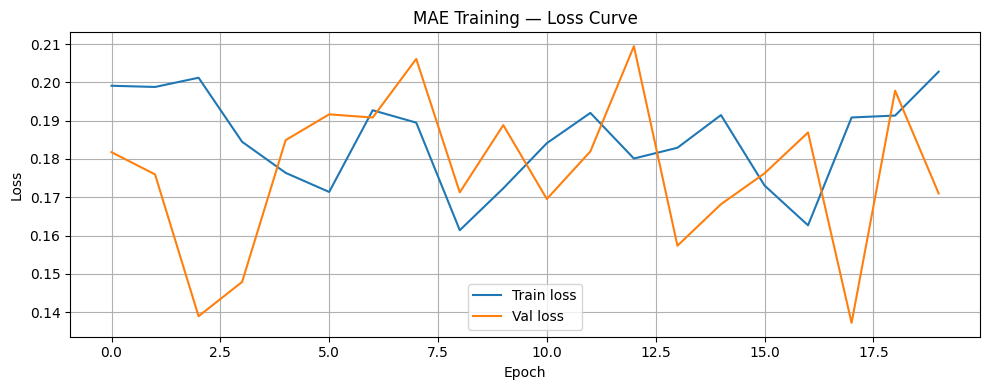

Loss curve saved → loss_curve.png


In [56]:
# =============================================================================
# 8. LOSS CURVE
# =============================================================================
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses,   label="Val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("MAE Training — Loss Curve")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=120)
plt.show()
print("Loss curve saved → loss_curve.png")